In [124]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from datetime import datetime
import  seaborn as sns
import os
sns.set()

Loading Data

In [125]:
# Load the high-pay data
high_pay_data = pd.read_csv('./Data/cleaned_high_pay_data.csv')

# Load the shapefile into a GeoDataFrame
shapefile_path = './us_state/us_state.shp'
us_states = gpd.read_file(shapefile_path)


In [ ]:
def StatesPlot(df, column_to_plot, cmap='viridis', label_color='black', label_size=6,
               title='United States Map', filename='us_map.png', min_value=None, max_value=None,
               edge_color='black', edge_linewidth=0.5):
    """
    Plots a US map based on state data and a specified column (e.g., income or education levels).

    Parameters:
    df (GeoDataFrame): Geodataframe containing the state geometries and data to plot.
    column_to_plot (str): Column name representing the data to be visualized (e.g., income levels, education levels).
    cmap (str): Color map to use for visualization.
    label_color (str): Color of the state labels.
    label_size (int): Font size of the state labels.
    title (str): Title of the plot.
    filename (str): Base name of the file to save the plot (without extension).
    min_value (float, optional): Minimum value to be used for color scaling.
    max_value (float, optional): Maximum value to be used for color scaling.
    edge_color (str): Color of the state borders.
    edge_linewidth (float): Width of the state borders.

    Returns:
    None
    """
    
    # Ensure the column exists in the dataframe
    if column_to_plot not in df.columns:
        print(f"Error: '{column_to_plot}' column not found in the DataFrame.")
        return

    # Remove rows with missing values in the specified column
    df = df.dropna(subset=[column_to_plot])

    # If min and max values are not provided, set them based on the column's data
    min_value = min_value or df[column_to_plot].min()
    max_value = max_value or df[column_to_plot].max()

    # Create a plot with a specified size
    fig, ax = plt.subplots(figsize=(15, 10), dpi=300)
    ax.set_axis_off()  # Hide the axis for a cleaner map view

    # Plot the state geometries using the specified column for color mapping
    df.plot(column=column_to_plot, ax=ax, alpha=0.7, cmap=cmap, linewidth=edge_linewidth, edgecolor=edge_color,
            vmin=min_value, vmax=max_value)

    # Add a color bar to represent the data values
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min_value, vmax=max_value))
    sm.set_array([])  # Create an empty array to avoid errors with ScalarMappable
    fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04, aspect=10)

    # Add a title to the plot
    plt.title(title, fontsize=16)

    # Add state labels (abbreviations) on the map
    for idx, row in df.iterrows():
        try:
            # Get the centroid of the state geometry
            centroid = row['geometry'].centroid
            # Place the state abbreviation at the centroid
            ax.text(centroid.x, centroid.y, row['STUSPS'], fontsize=label_size, ha='center', color=label_color)
        except Exception:
            pass  # Skip any errors (e.g., for geometries with no centroid)

    # Ensure the Images directory exists
    os.makedirs("Images", exist_ok=True)

    # Create the full path for the file, checking if it already exists
    filepath = os.path.join("Images", filename)
    if os.path.exists(filepath):
        print(f"Error: File {filename} already exists. Not saving the plot.")
    else:
        # Save the plot as a PNG file if it doesn't already exist
        plt.savefig(filepath, bbox_inches='tight', dpi=300)
        print(f"Map saved to {filepath}")

    # Display the plot
    plt.show()


** 1. Question: **   What is the dominant education level for high-paying jobs (earning $100K+) across different states, and how does this reflect regional job market demands?

In [127]:
# Data Preparation
dominant_education = (
    high_pay_data.groupby(['State Abbreviation', 'Education Level'])
    .size()
    .reset_index(name='Count')
)
# Sort by state and count, descending, and pick the dominant education
dominant_education = dominant_education.sort_values(
    ['State Abbreviation', 'Count'], ascending=[True, False]
).drop_duplicates(subset='State Abbreviation', keep='first')

# Merge with us_states GeoDataFrame for visualization
geo_dominant_education = pd.merge(
    us_states, dominant_education, left_on='STUSPS', right_on='State Abbreviation', how='left'
)

In [129]:
# Ensure `geo_dominant_education` is a GeoDataFrame for spatial plotting
geo_dominant_education = gpd.GeoDataFrame(geo_dominant_education, geometry='geometry')
# exclude ALska and huwaii
geo_dominant_education=geo_dominant_education.loc[~geo_dominant_education['STUSPS'].isin(['AK', 'HI'])]

In [ ]:
# define function 
def Education_State(df, column, title, filename,cmap='tab20'):
    """
    Plots a map of the dominant education level for each state, and saves it with a unique filename.
    
    Parameters:
    df (GeoDataFrame): GeoDataFrame containing state geometries and education data.
    column_to_plot (str): Column name for the data to be visualized (e.g., 'Education Level').
    cmap (str): Color map for categorical data.
    title (str): Title for the plot.
    filename (str): Base name for the file to be saved (without extension).
    
    Returns:
    None
    """
    # Set up the plot
    fig, ax = plt.subplots(1, 1, figsize=(15, 10))
    # Remove rows with missing values in the specified column
    df = df.dropna(subset=[column])
    # Plot the map with the dominant education level for each state
    df.plot(
        column=column_to_plot,
        ax=ax,
        cmap=cmap,
        legend=True,
        linewidth=0.5,
        edgecolor='black',
        legend_kwds={'title': "Education Level by State"}
    )

    # Add state abbreviations to the map
    for idx, row in geo_dominant_education.iterrows():
        centroid = row['geometry'].centroid  # Get the centroid of each state
        ax.text(centroid.x, centroid.y, row['STUSPS'], fontsize=10, ha='center', color='black')

    # Title for the map
    plt.title(title, fontsize=16)

    # Turn off axis for cleaner visualization
    plt.axis('off')

    # Move the legend to the best position
    ax.get_legend().set_bbox_to_anchor((1, 0.5))

    # Ensure the Images directory exists
    os.makedirs("Images", exist_ok=True)

    # Create the full path for the file, checking if it already exists
    filepath = os.path.join("Images", filename)
    if os.path.exists(filepath):
        print(f"Error: File {filename} already exists. Not saving the plot.")
    else:
        # Save the plot as a PNG file if it doesn't already exist
        plt.savefig(filepath, bbox_inches='tight', dpi=300)
        print(f"Map saved to {filepath}")

    # Show the plot
    plt.show()

Error: File dominant_education_by_state.png already exists. Not saving the plot.


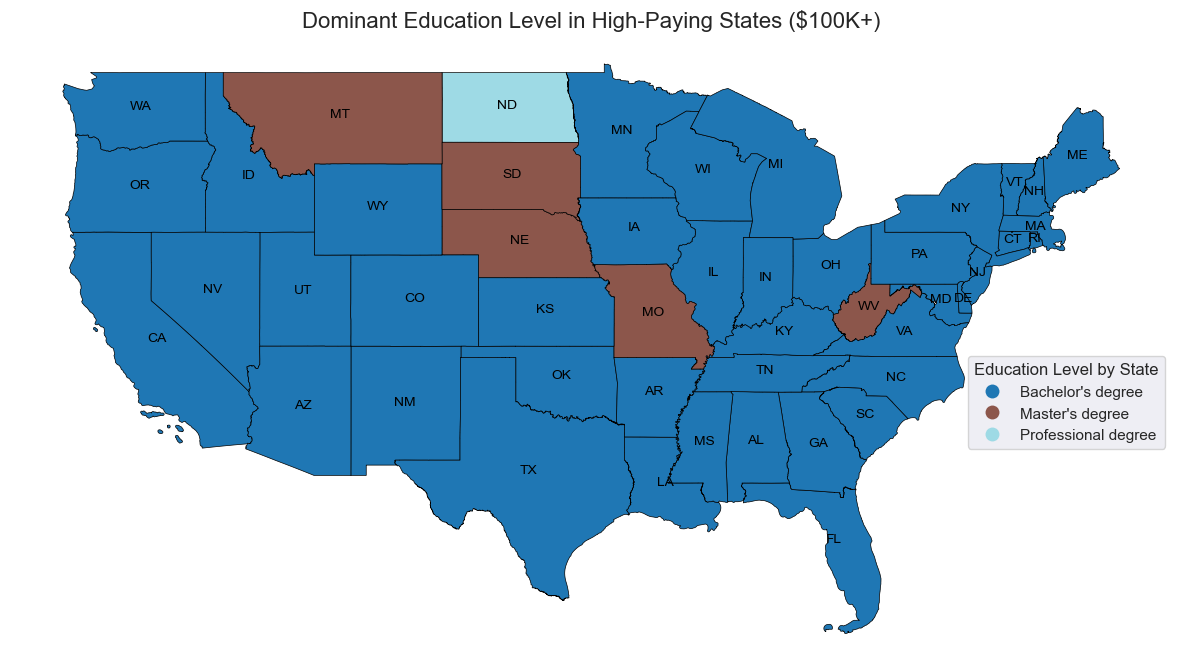

In [ ]:
#data viz
Education_state(geo_dominant_education, column='Education Level',
        title='Dominant Education Level in High-Paying States ($100K+)',filename='Dominant_education_by_state.png')

2. - **Question:** Which states have the highest concentration of high-paying jobs ($100K+ annual income)?
- **Answer**:the states with the highest concentration of high-paying jobs (those earning $100K+ annually) are typically marked by a large number of these jobs relative to the state's total employment. Based on your data, the states with the highest concentration of high-paying jobs (in terms of both the absolute number of jobs and their distribution) include:

California (CA) – With a large economy and many industries offering high-paying positions, California consistently ranks among the top states for high-paying jobs.
New York (NY) – Known for its financial, tech, and healthcare sectors, New York also has a significant number of high-paying job opportunities.
Texas (TX) – Texas, with a booming energy sector and growing tech and healthcare industries, also has a high concentration of high-paying jobs.

In [96]:
# Calculate high-paying job totals and total jobs by state
job_data = (
    high_pay_data.groupby('State Abbreviation')
    .agg(High_Paying_Jobs=('Annual Income', 'size'), Total_Jobs=('Employment', 'size'))
    .reset_index()
)
#add the location tothe data frame
job_data['Location Quotient']=high_pay_data['Location Quotient']

# Merge with `us_states` GeoDataFrame for visualization or mapping purposes
job_data_geo = pd.merge(us_states, job_data, left_on='STUSPS', right_on='State Abbreviation', how='left')


In [97]:
# Convert the merged DataFrame into a GeoDataFrame with spatial geometry for plotting
job_data_geo = gpd.GeoDataFrame(job_data_geo, geometry=job_data_geo.geometry)

# Exclude Alaska (AK) and Hawaii (HI) from the data for easier mapping
job_data_geo = job_data_geo.loc[~job_data_geo['STUSPS'].isin(['AK', 'HI'])]

Error: File High-Paying Jobs Distribution.png already exists. Not saving the plot.


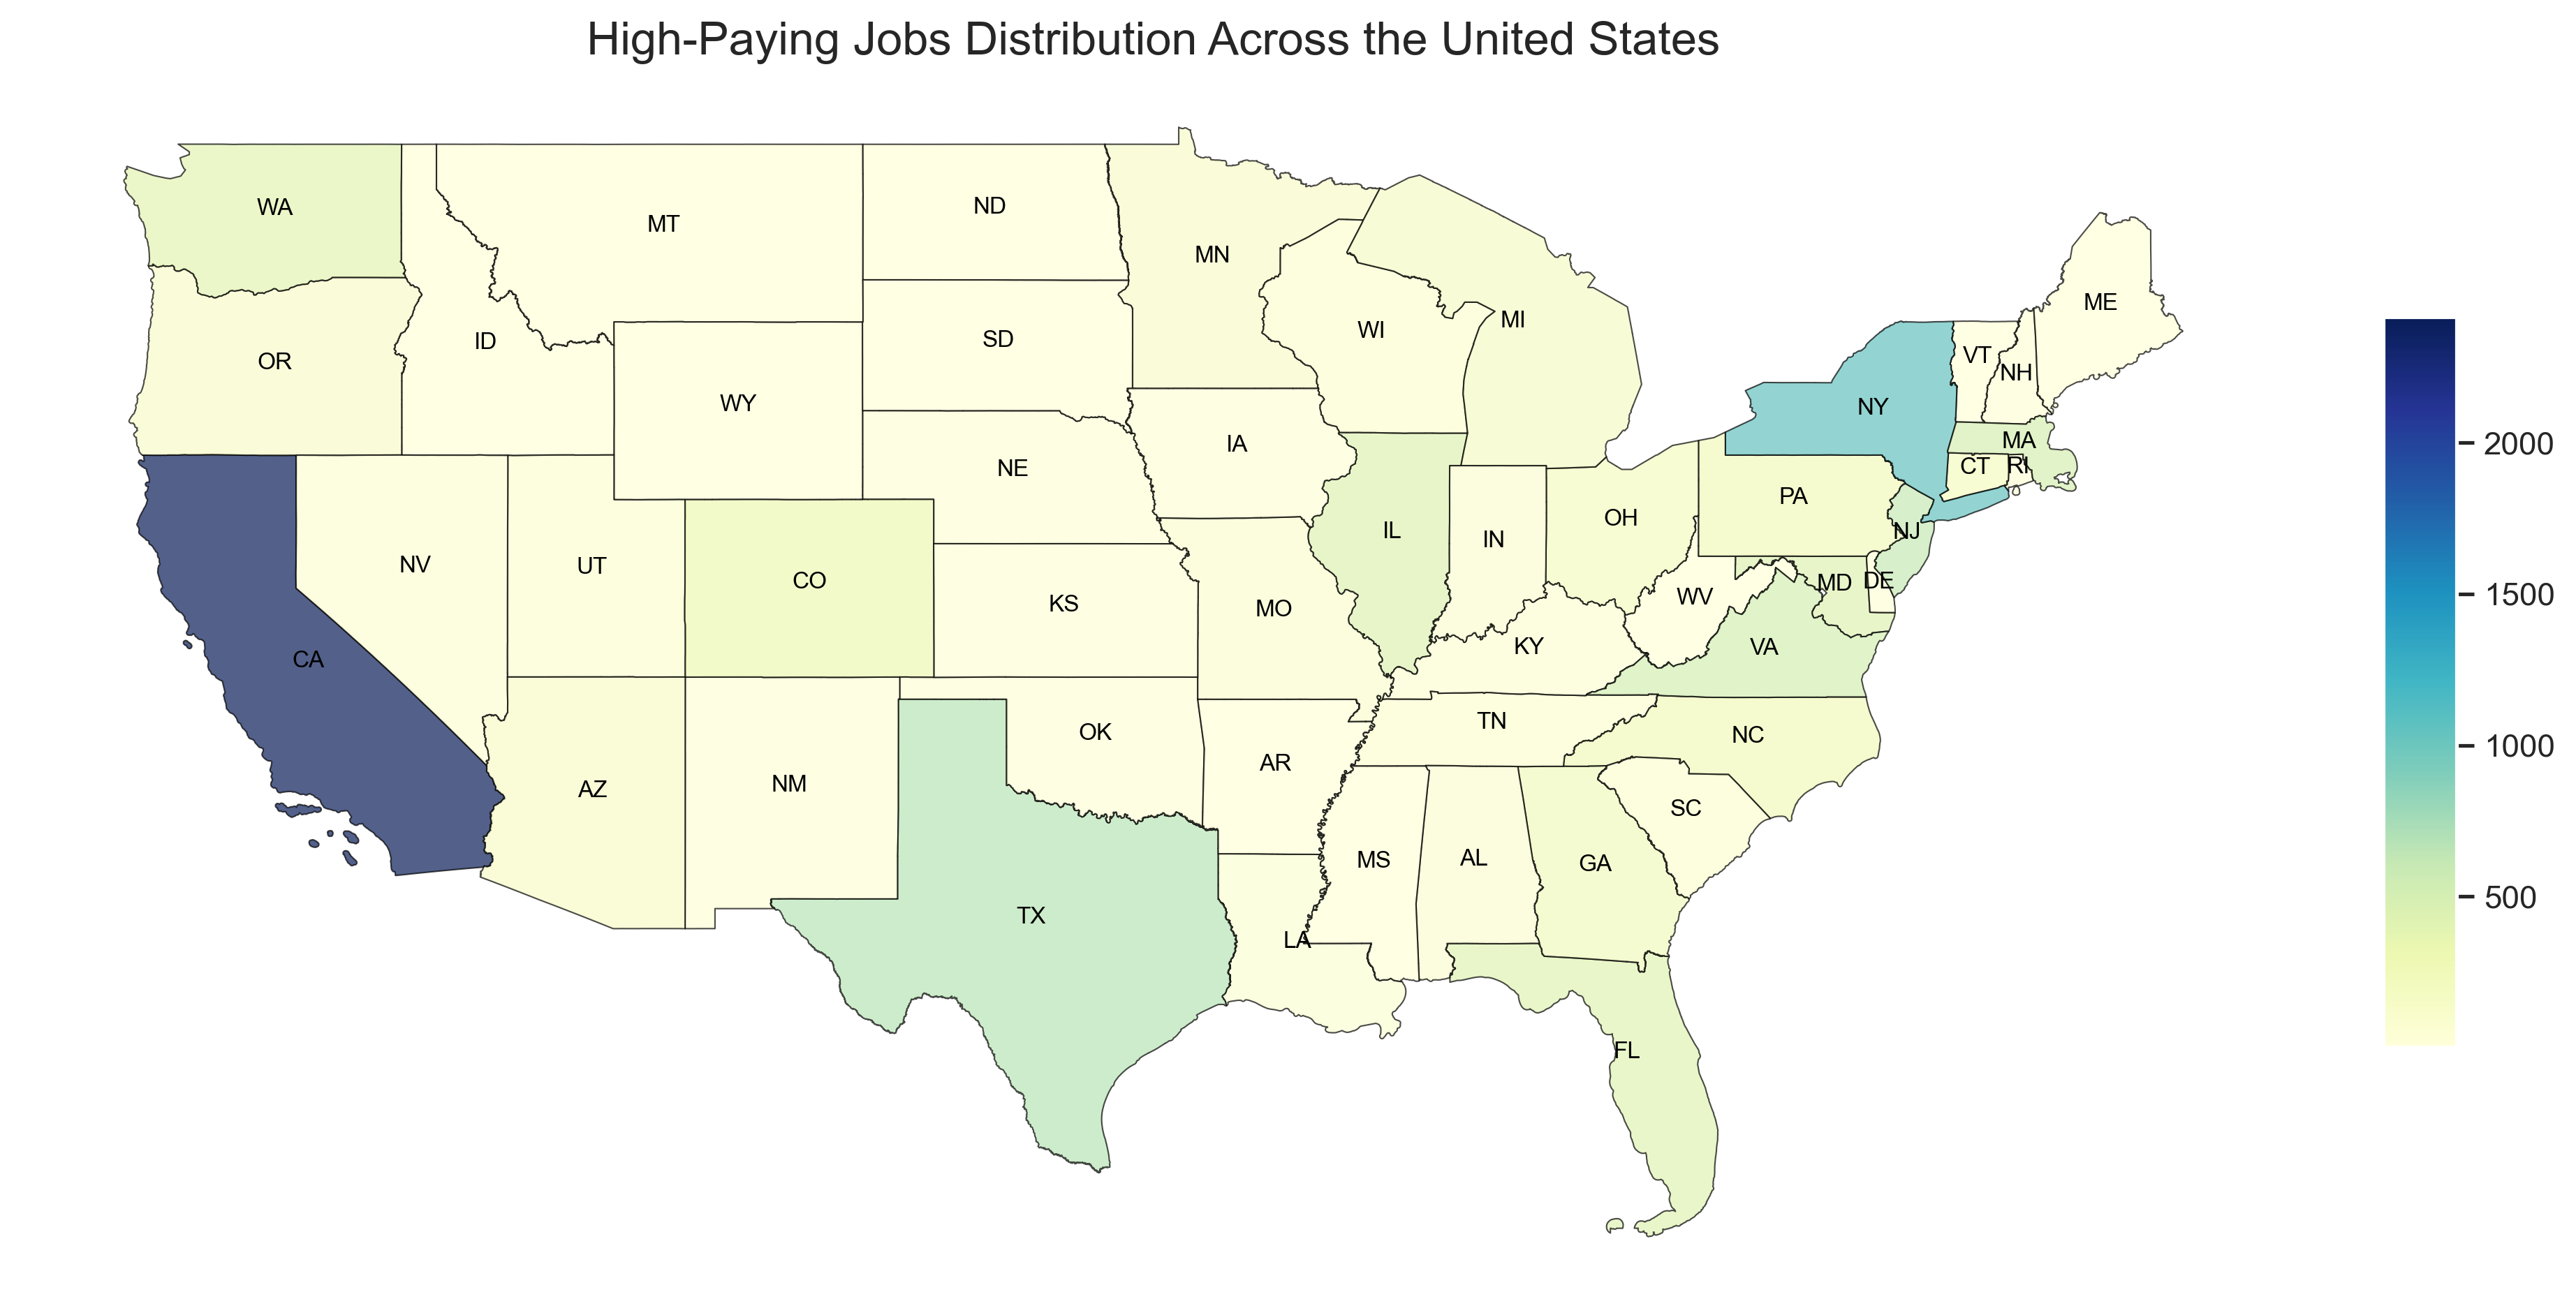

In [98]:
StatesPlot(
    df=job_data_geo,
    column_to_plot='High_Paying_Jobs',
    cmap='YlGnBu',
    label_color='black',
    label_size=8,
    title='High-Paying Jobs Distribution Across the United States',
    filename='High-Paying Jobs Distribution.png',
    edge_color='black'
)

- **Question**
:Which states have the highest concentration of high-paying jobs ($100K+ annual income) based on location quotient (LQ) values, and how can this be visualized on a map?
- **Answer**:  The Location Quotient (LQ) is a measure used to identify the concentration of specific industries or occupations in a state relative to the national average. When applied to high-paying jobs ($100K+ annual income), a high LQ value indicates that a particular state has a significantly higher concentration of these jobs compared to the national average.

Interpretation:
States with High LQ Values for High-Paying Jobs:
Idaho (ID) and Nebraska (NE) have the highest LQ values, meaning these states have an exceptionally high concentration of high-paying jobs in proportion to their total employment.
Montana (MT), Michigan (MI), and New York (NY) also have strong LQ values, indicating a relatively higher concentration of high-paying jobs compared to the national average.
These states will stand out as darkest shades on the LQ map, showing they have the highest concentration of high-paying jobs.

Visualization:
Map Interpretation: On the map, states like Idaho, Nebraska, Montana, Michigan, and New York will appear with darker colors, indicating they have a higher concentration of high-paying jobs compared to the national average.
The states with lower LQ values (i.e., less concentrated high-paying jobs) will appear in lighter colors, reflecting a lower concentration of these jobs relative to the national average.
Summary:
Darker-colored states (e.g., ID, NE) represent those with the highest concentration of high-paying jobs ($100K+ annual income) based on Location Quotient (LQ).
Lighter-colored states represent those with a lower concentration of high-paying jobs.


Map saved to Images\high_paying_jobs_LQ_distribution_.png


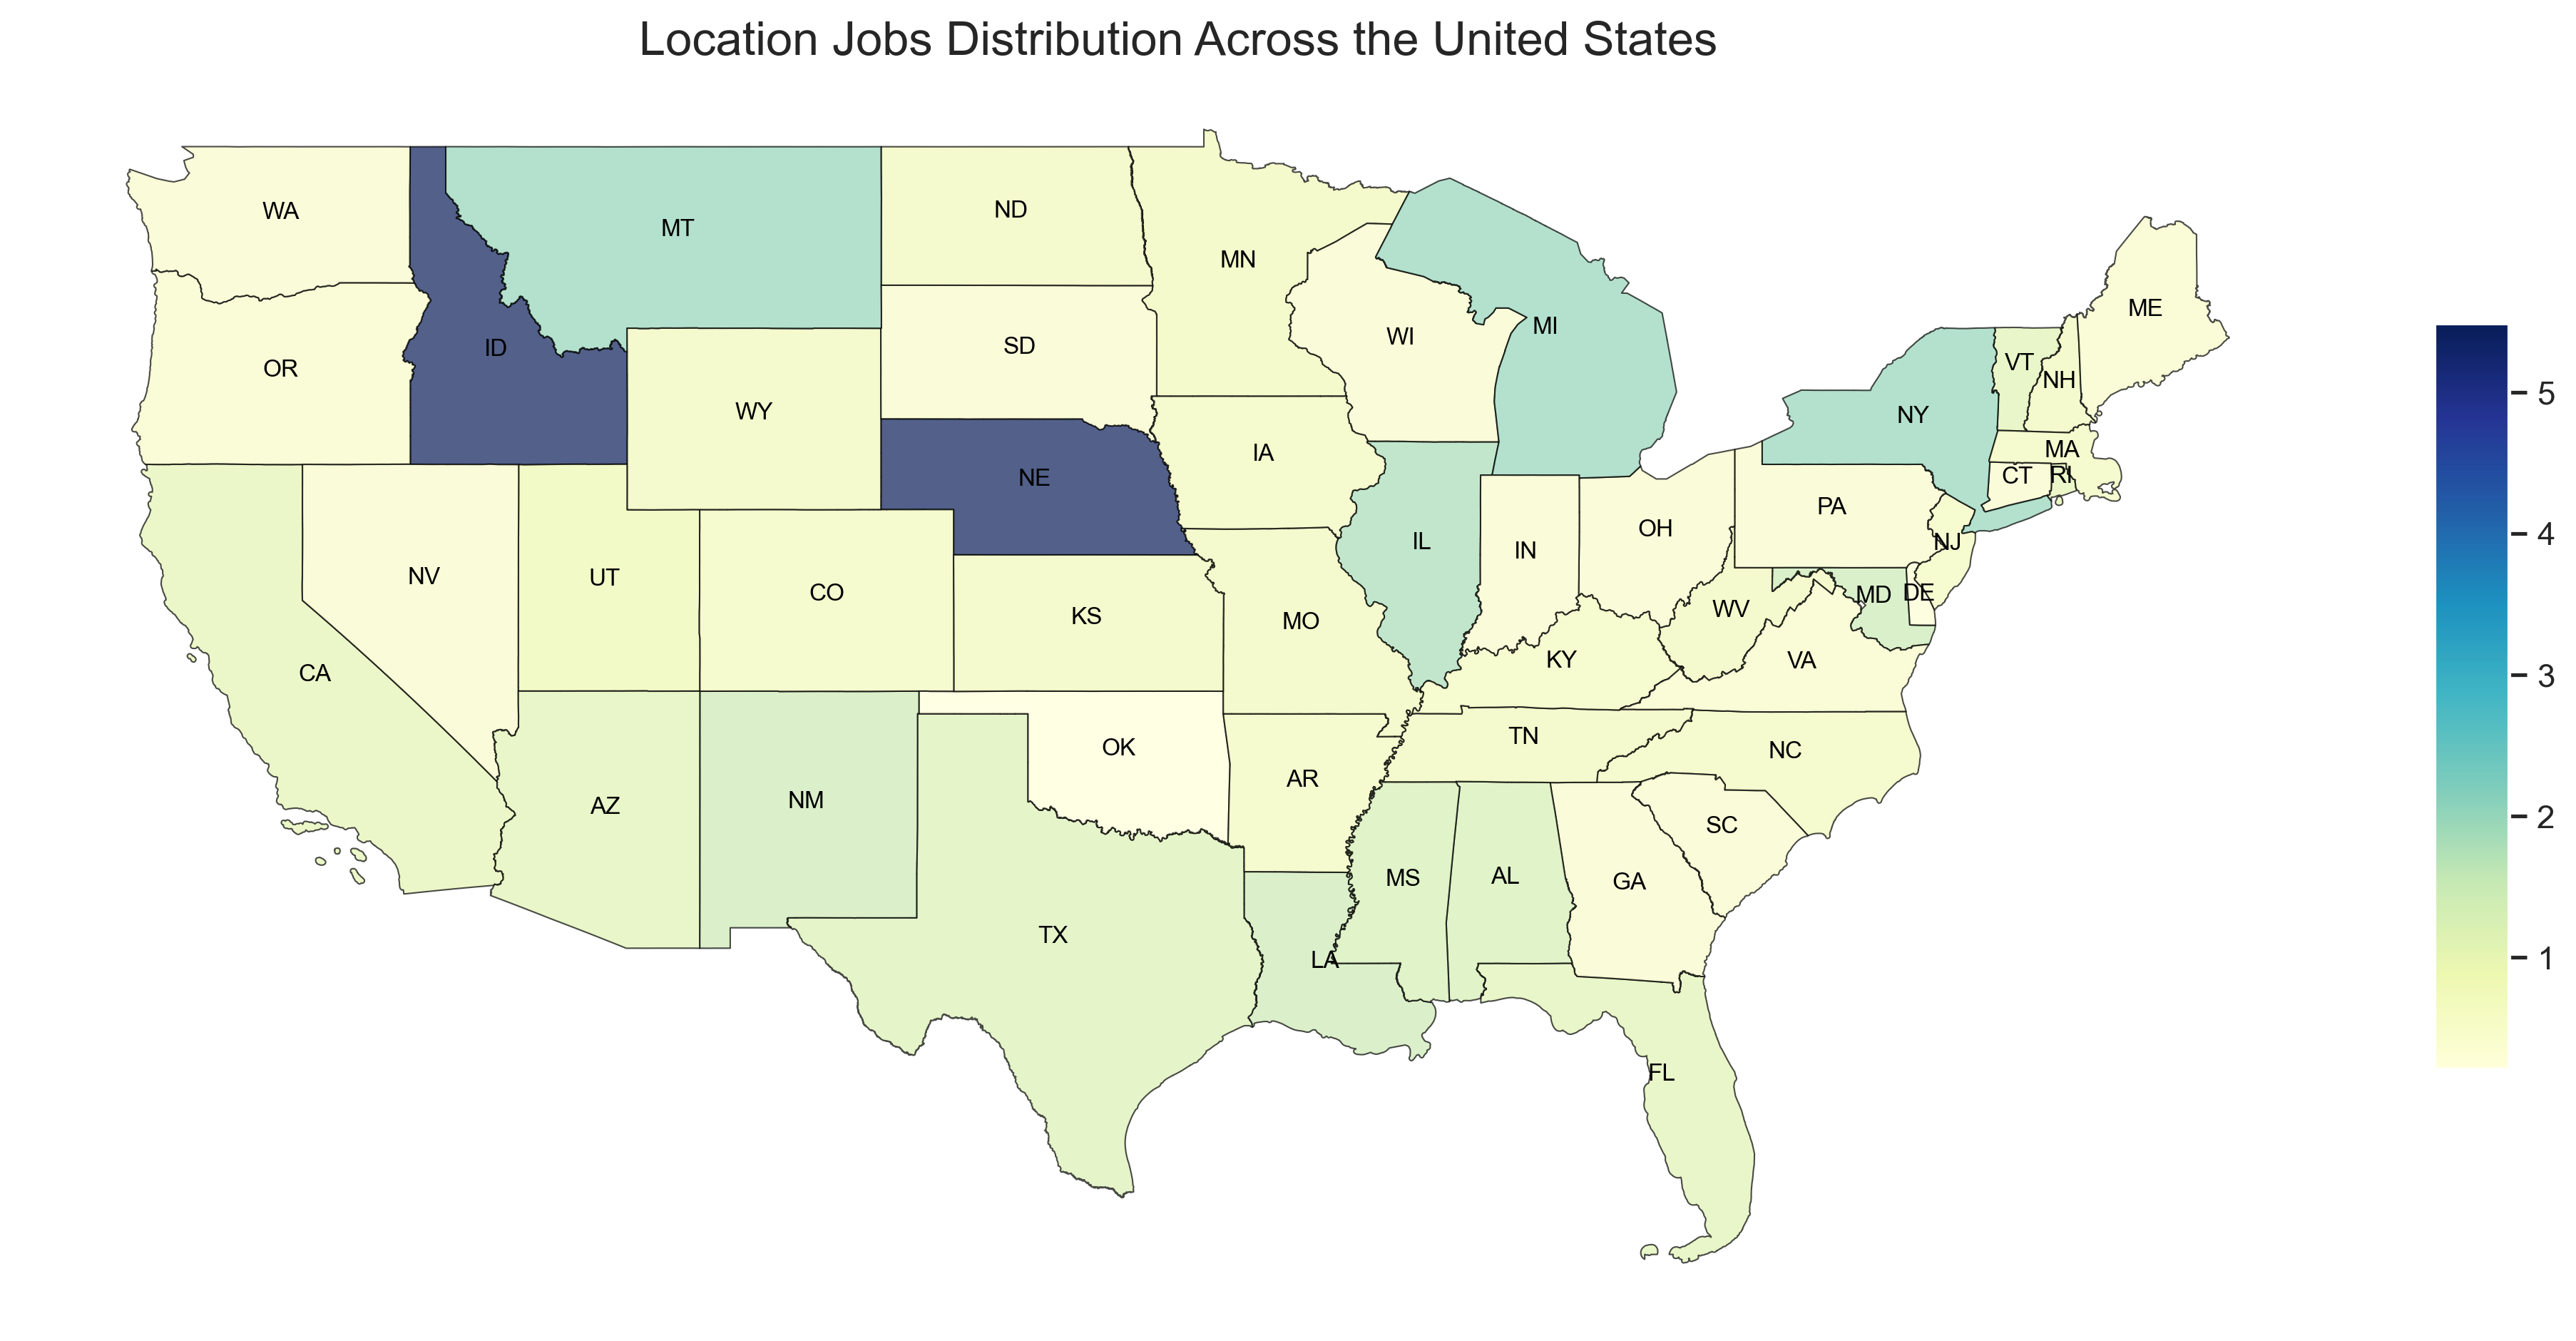

In [99]:
StatesPlot(
    df=job_data_geo,
    column_to_plot='Location Quotient',
    cmap='YlGnBu',
    label_color='black',
    label_size=8,
    title='Location Jobs Distribution Across the United States',
    filename='high_paying_jobs_LQ_distribution_.png',
    edge_color='black'
)

The darker regions on the map represent states with either:

Higher Location Quotients (LQ): For instance, Idaho (ID) and Nebraska (NE) have darker shades, indicating a higher concentration of jobs in specific industries compared to the national average. These states are more specialized in particular sectors.

More High-Paying Jobs: States like California (CA), New York (NY), and Texas (TX) have more high-paying job opportunities (those earning $100K+), and they are shaded lighter, reflecting the large number of such jobs available in these regions.

In summary, the darker regions such as Idaho (ID) and Nebraska (NE) represent states with a higher concentration of specialized jobs (higher LQ), while the lighter regions like California (CA), New York (NY), and Texas (TX) reflect states with more high-paying job opportunities.

In [100]:
# Calculate the average annual income by state
A_income_state = (high_pay_data.groupby(['State Abbreviation'])['Annual Income']
                  .mean()
                  .reset_index()
                  .round(2))
                
# Merge the calculated annual income data with state geometries
# 'left_on' is the 'State Abbreviation' from A_income_state, and 'right_on' is the 'STUSPS' from the US states GeoDataFrame
geo_income_data = A_income_state.merge(us_states, left_on='State Abbreviation', right_on='STUSPS')

# Convert the merged DataFrame into a GeoDataFrame with spatial geometry for plotting
geo_income_data = gpd.GeoDataFrame(geo_income_data, geometry=geo_income_data.geometry)

# Exclude Alaska (AK) and Hawaii (HI) from the data for easier mapping
geo_income_data = geo_income_data.loc[~geo_income_data['STUSPS'].isin(['AK', 'HI'])]


Map saved to Images\Average_Highest_Income_state.png


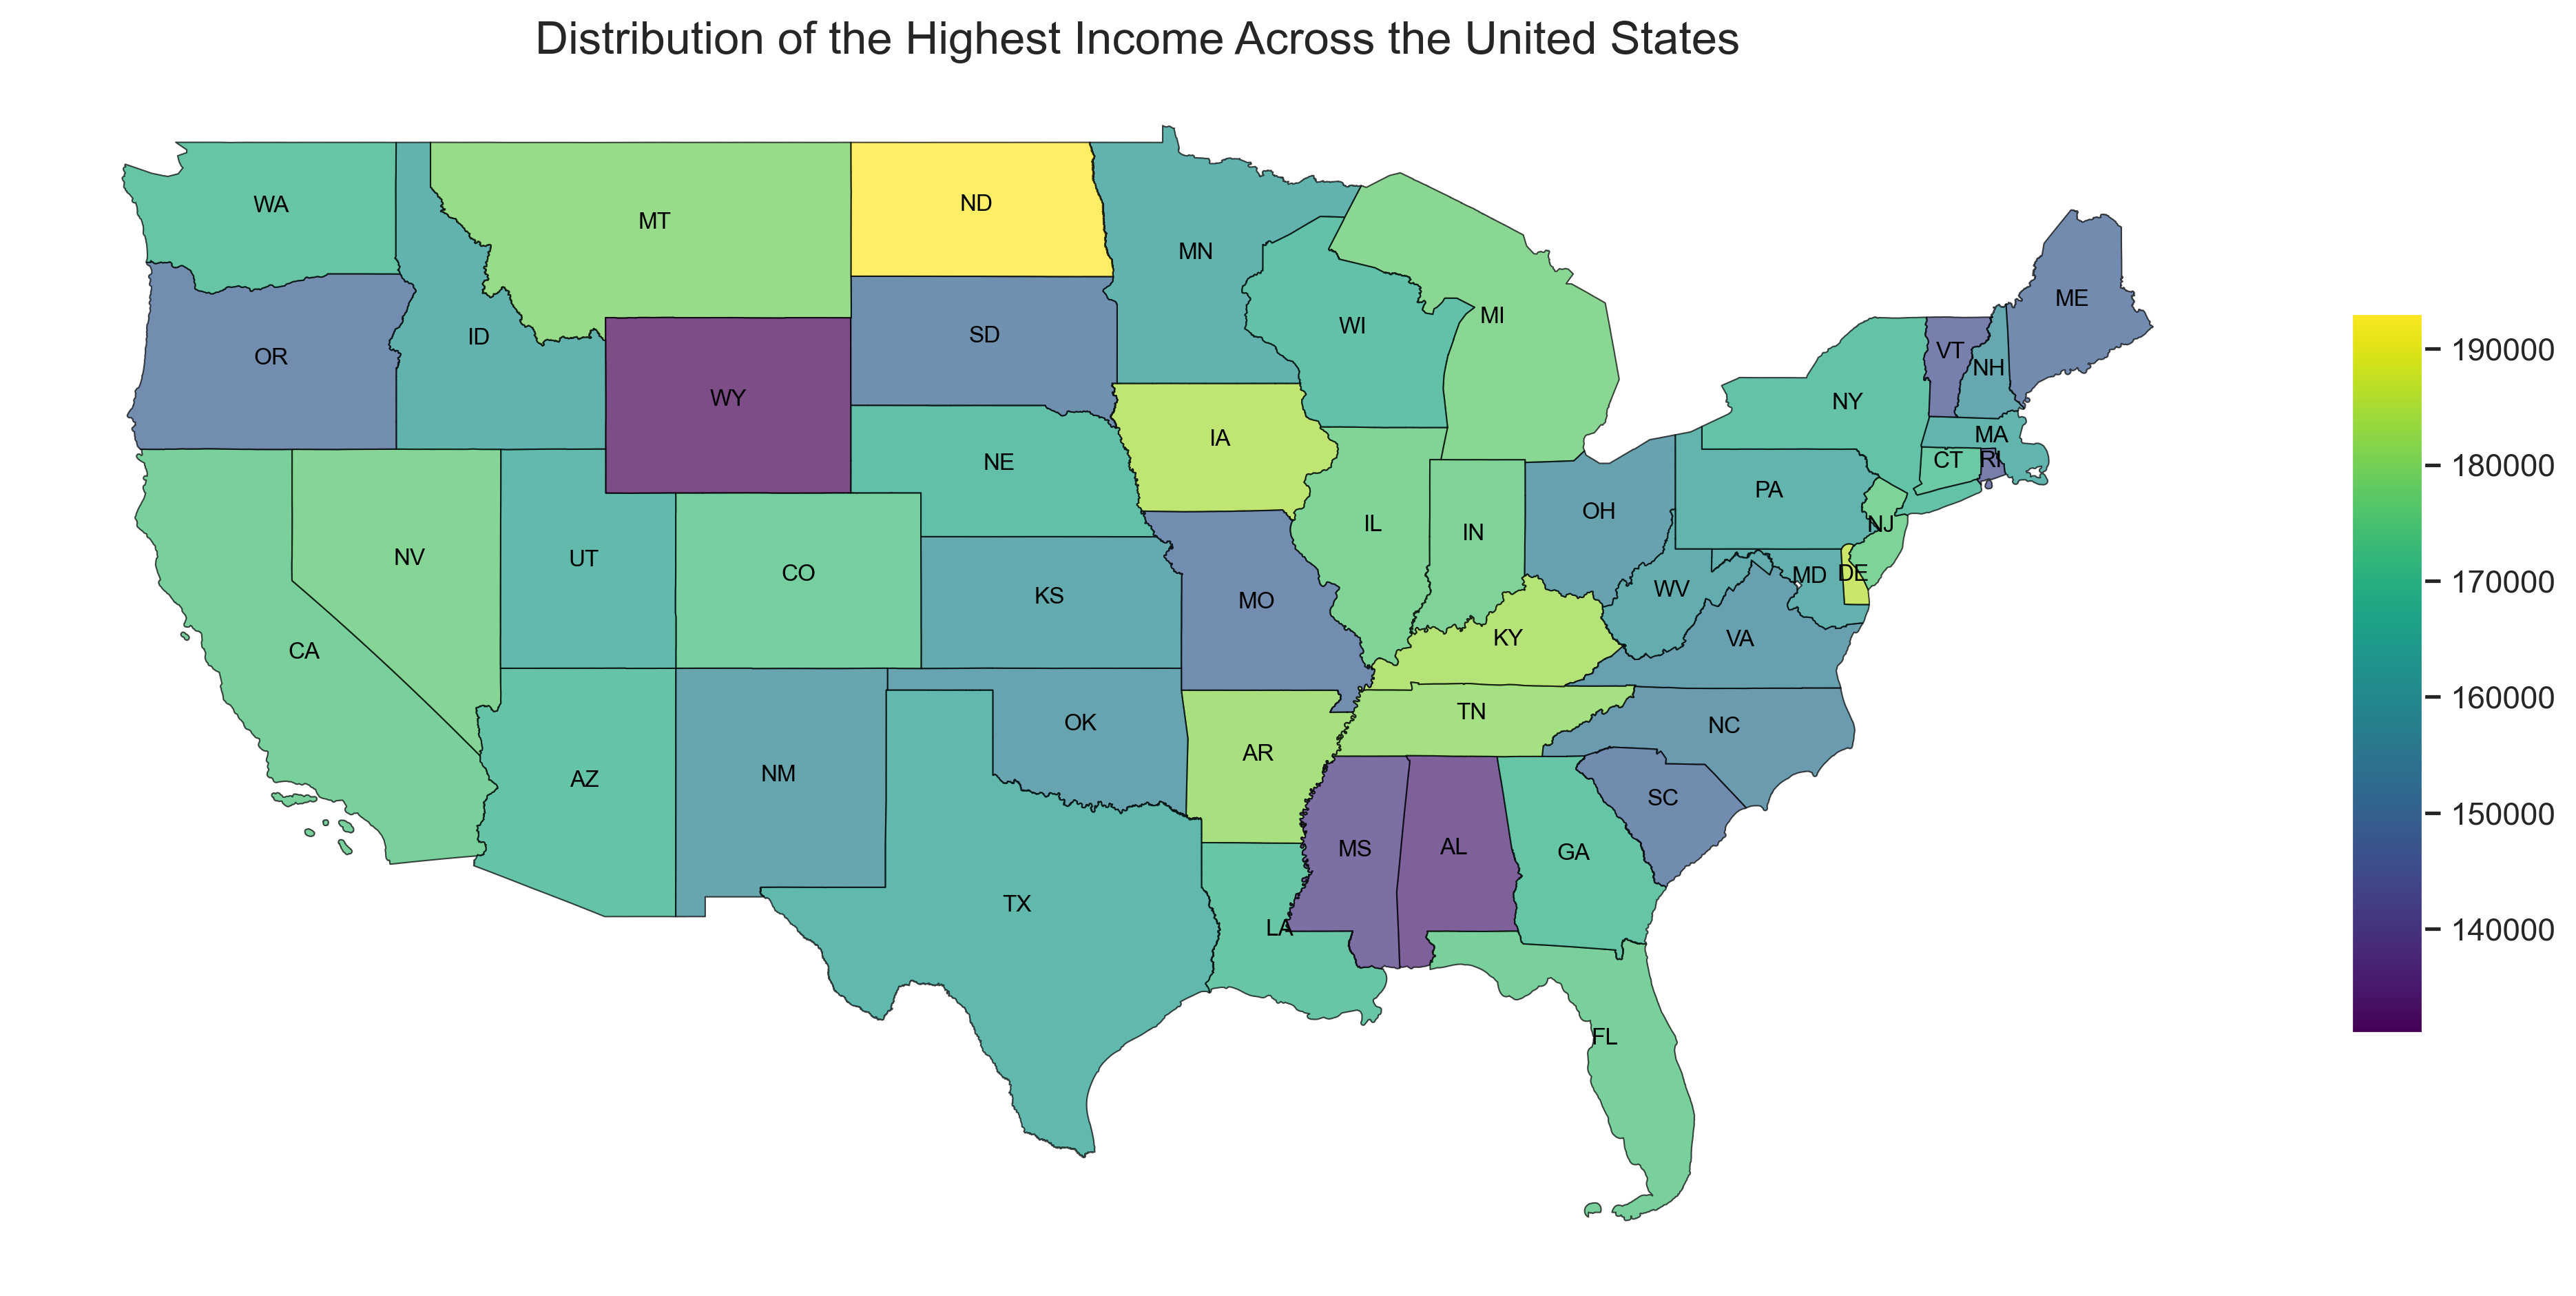

In [101]:
StatesPlot(
    df=geo_income_data,
    column_to_plot='Annual Income',
    cmap='viridis',
    label_color='black',
    label_size=8,
    title='Distribution of the Highest Income Across the United States',  # Updated title
    filename='Average_Highest_Income_state.png',  
    edge_color='black'
)

In [ ]:
# Step 1: Filter and Aggregate the Data
# Group by State and Gender to get counts
gender_counts = high_pay_data.groupby(['State Abbreviation', 'Gender']).size().unstack(fill_value=0)

# Step 2: Calculate Percentages
gender_counts['Total'] = gender_counts.sum(axis=1)
gender_counts['Male_Percentage'] = (gender_counts['Male'] / gender_counts['Total']) * 100
gender_counts['Female_Percentage'] = (gender_counts['Female'] / gender_counts['Total']) * 100

# Reset index to have State as a column
gender_counts.reset_index(inplace=True)

# Step 3: Merge with Geographical Data
geo_gender_df = us_states.merge(gender_counts, left_on='STUSPS', right_on='State Abbreviation', how='left')


In [152]:
# goe_geneder_df=merged_data[['STUSPS','geometry','Male_Percentage','Female_Percentage']]
#exclude ak and hi
geo_gender_df = geo_gender_df.loc[~geo_gender_df['STUSPS'].isin(['AK', 'HI'])]

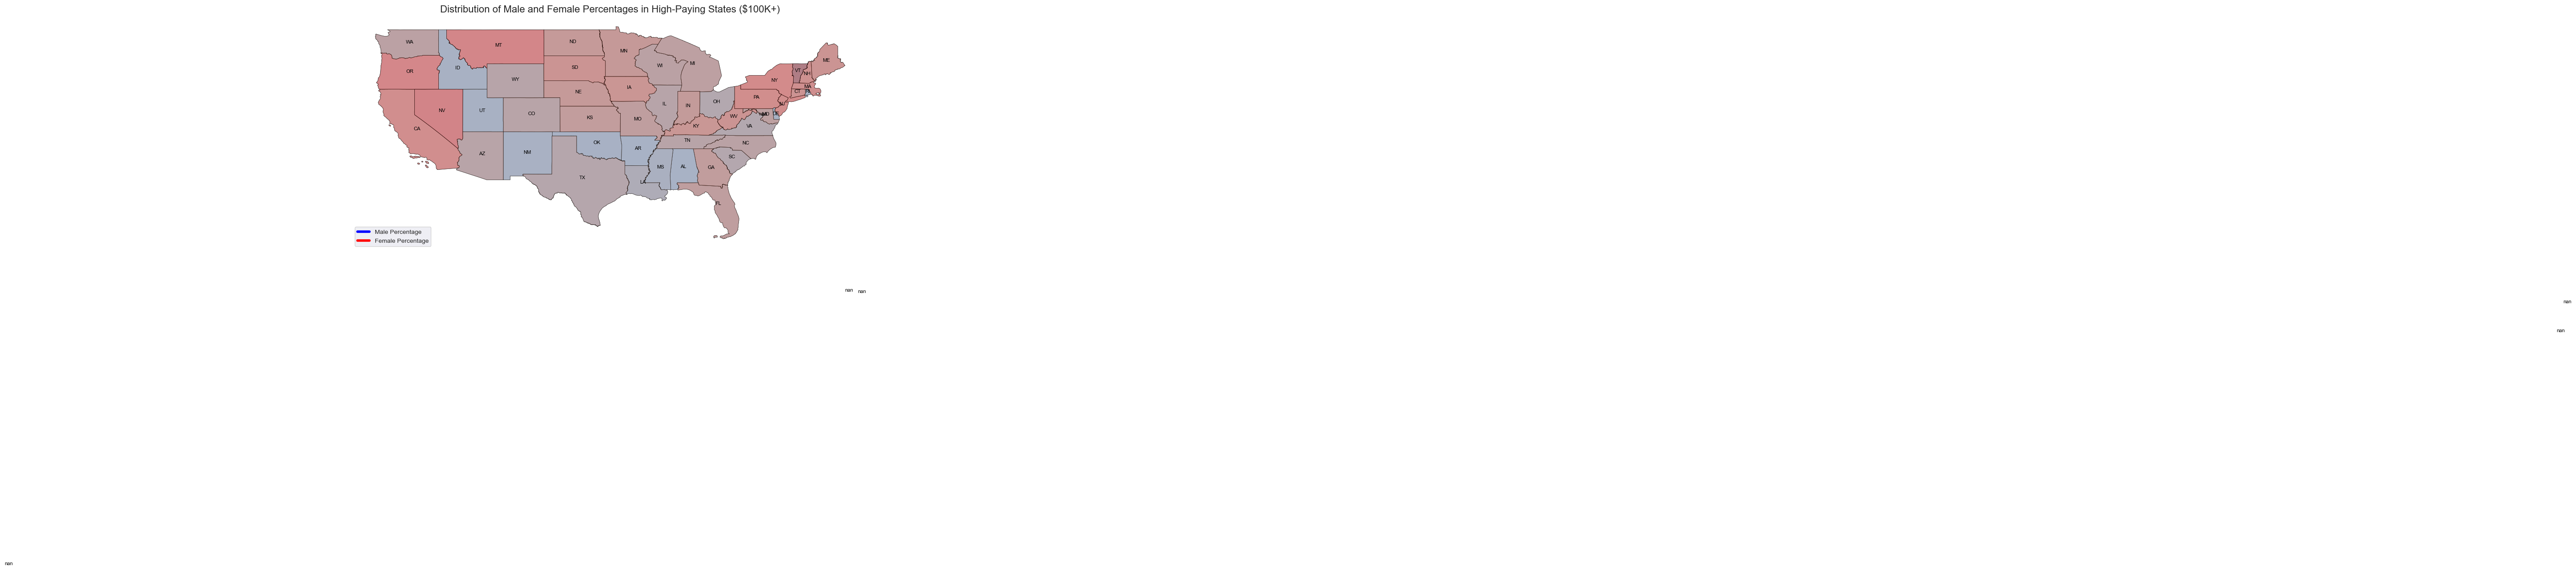

In [137]:
# Set up the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the map with male percentage
geo_gender_df.plot(
    column='Male_Percentage',ax=ax,cmap='Blues',linewidth=0.5,edgecolor='black',alpha=0.7, label='Male Percentage')

# Overlay the female percentage with a different color
geo_gender_df.plot(
    column='Female_Percentage',ax=ax,cmap='Reds',linewidth=0.5, edgecolor='black',alpha=0.5, label='Female Percentage')

# Add state abbreviations to the map
for _, row in geo_gender_df.iterrows():
    ax.text(
        row['geometry'].centroid.x,
        row['geometry'].centroid.y,
        row['State Abbreviation'],
        horizontalalignment='center',
        fontsize=8,
        color='black'
    )

# Add a custom legend for Male and Female Percentages
blue_patch = plt.Line2D([0], [0], color='blue', lw=4, label='Male Percentage')
red_patch = plt.Line2D([0], [0], color='red', lw=4, label='Female Percentage')
plt.legend(handles=[blue_patch, red_patch], loc='lower left', fontsize=10)

# Title for the map
plt.title('Distribution of Male and Female Percentages in High-Paying States ($100K+)', fontsize=16)

# Turn off axis for a cleaner visualization
plt.axis('off')

# Save the plot with a dynamic filename
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"Images/Gender_distribution_{timestamp}.png"
plt.savefig(filename, bbox_inches='tight', dpi=300)

# Show the plot
plt.show()


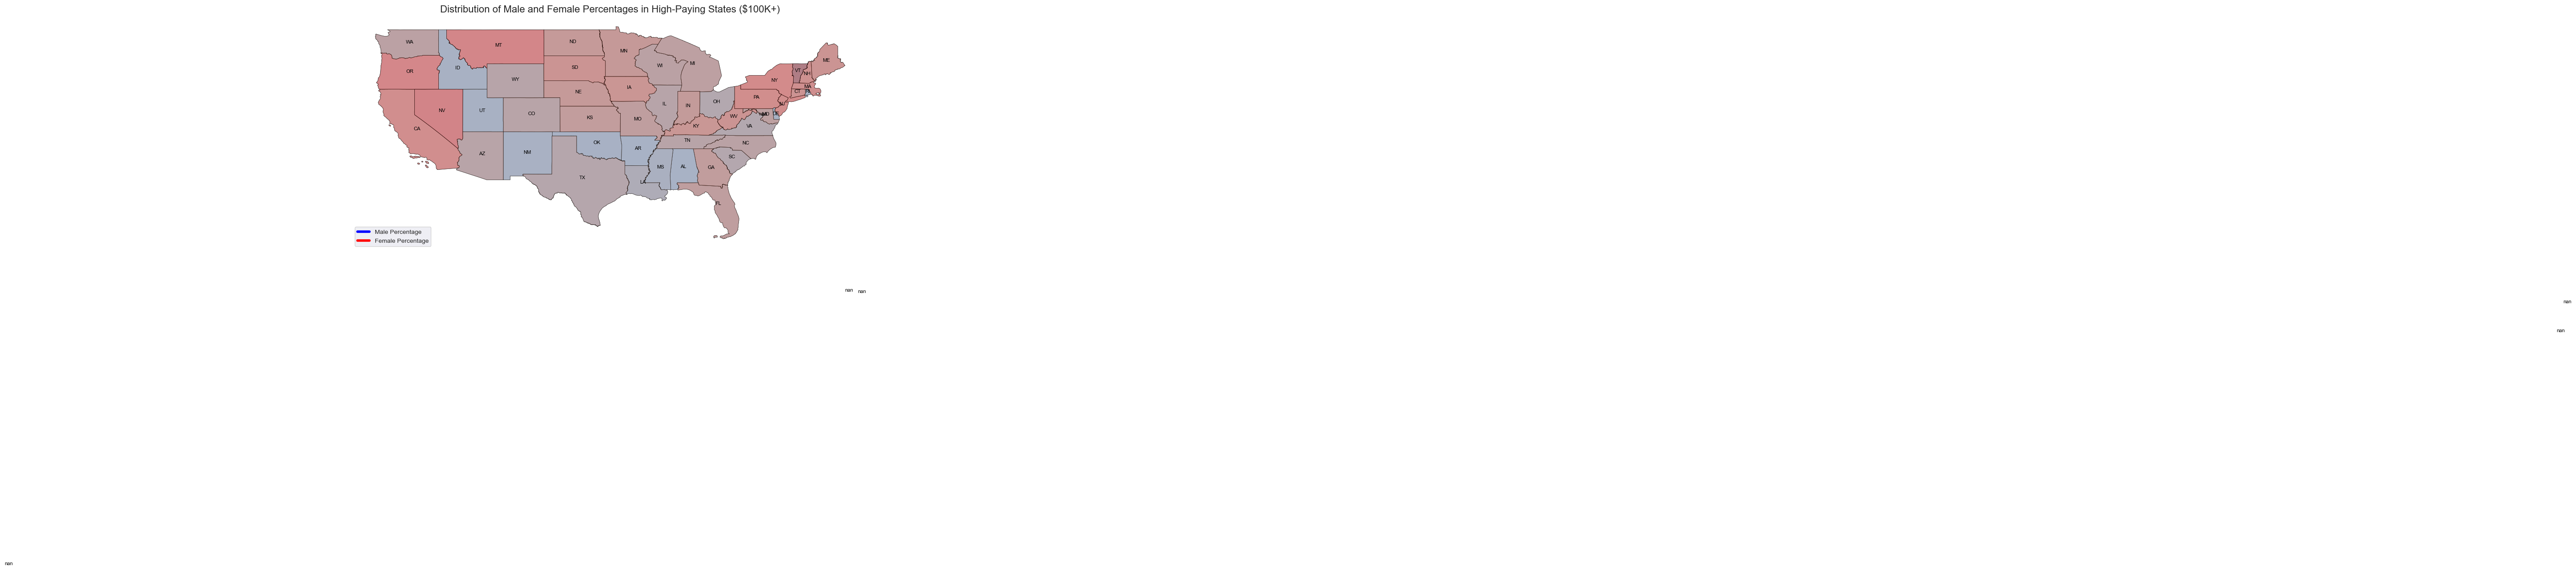

In [ ]:
import matplotlib.pyplot as plt
import datetime
import os

# Ensure the Images directory exists
os.makedirs("Images", exist_ok=True)

# Set up the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the map with male percentage
geo_gender_df.plot(
    column='Male_Percentage', ax=ax, cmap='Blues', linewidth=0.5, edgecolor='black', alpha=0.7, label='Male Percentage'
)

# Overlay the female percentage with a different color
geo_gender_df.plot(
    column='Female_Percentage', ax=ax, cmap='Reds', linewidth=0.5, edgecolor='black', alpha=0.5, label='Female Percentage'
)

# Add state abbreviations to the map
for _, row in geo_gender_df.iterrows():
    ax.text(
        row['geometry'].centroid.x,
        row['geometry'].centroid.y,
        row['State Abbreviation'],
        horizontalalignment='center',
        fontsize=8,
        color='black'
    )

# Add a custom legend for Male and Female Percentages
blue_patch = plt.Line2D([0], [0], color='blue', lw=4, label='Male Percentage')
red_patch = plt.Line2D([0], [0], color='red', lw=4, label='Female Percentage')
plt.legend(handles=[blue_patch, red_patch], loc='lower left', fontsize=10)

# Title for the map
plt.title('Distribution of Male and Female Percentages in High-Paying States ($100K+)', fontsize=16)

# Turn off axis for a cleaner visualization
plt.axis('off')

# Save the plot with a dynamic filename
filename = f"Images/Gender_distribution.png"
plt.savefig(filename, bbox_inches='tight', dpi=300)

# Show the plot
plt.show()

Map saved to Images\Male_Percentage_state.png


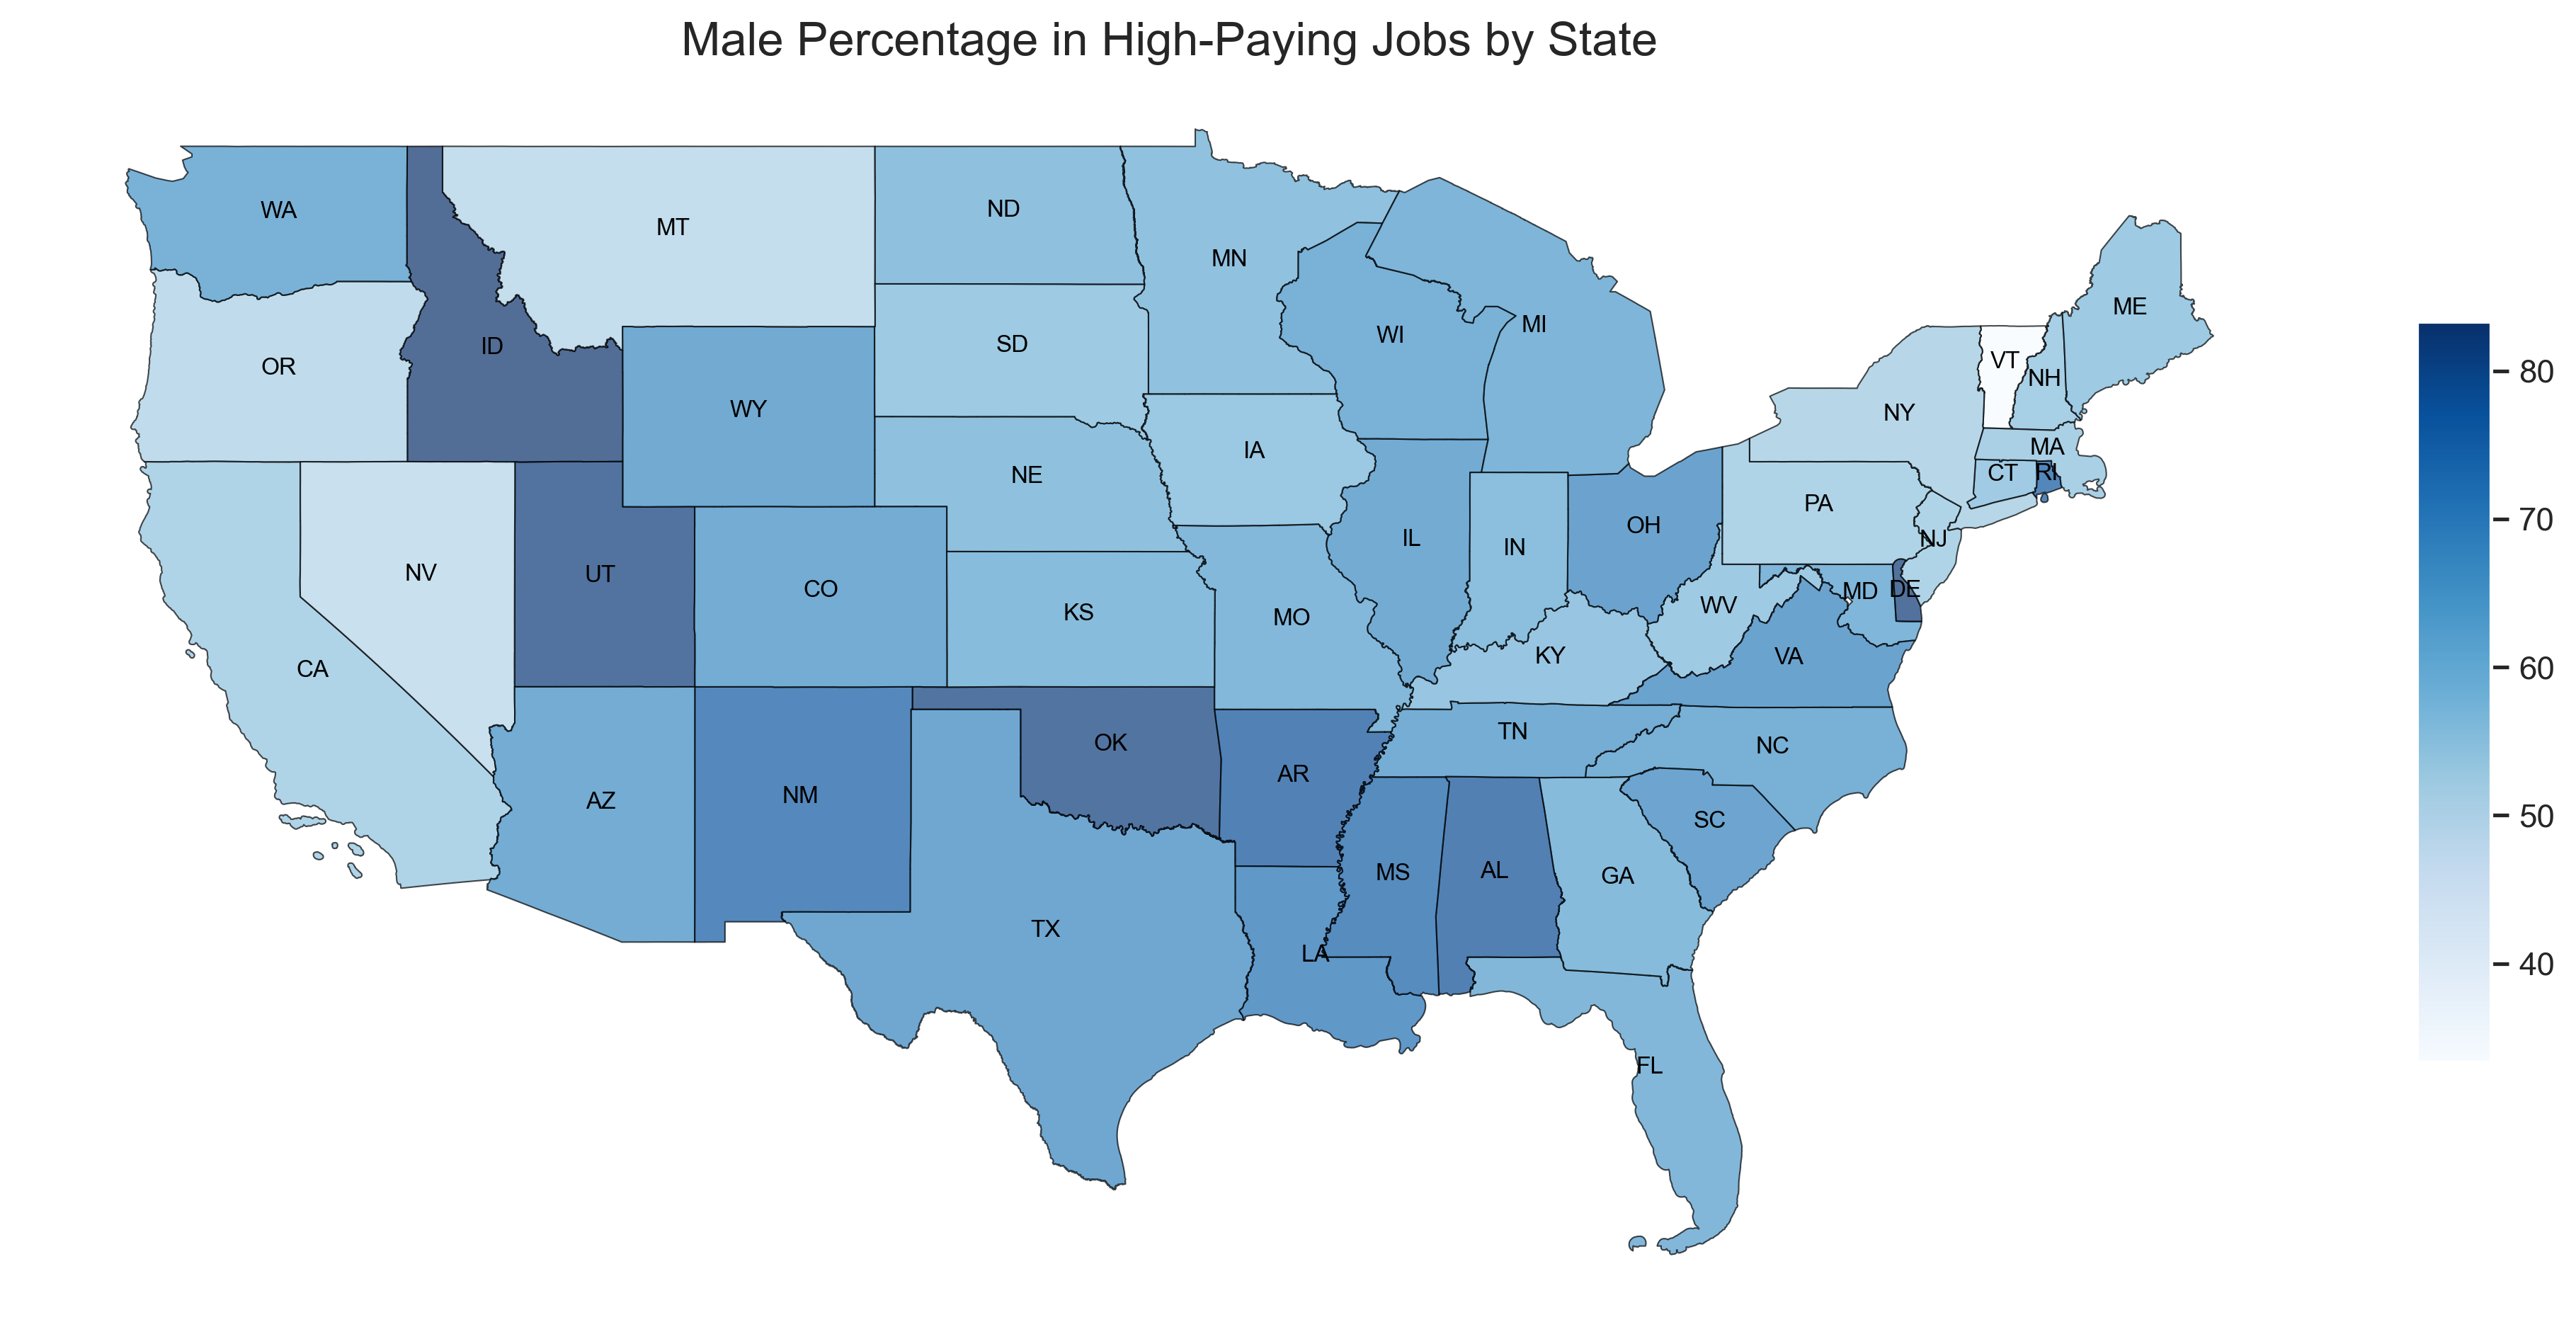

In [105]:

StatesPlot(
    df=geo_gender_df,
    column_to_plot='Male_Percentage',
    cmap='Blues',
    label_color='black',
    label_size=8,
    title='Male Percentage in High-Paying Jobs by State',  # Updated title
    filename='Male_Percentage_state.png',  
    edge_color='black'
)


Map saved to Images\Female_Percentage_state.png


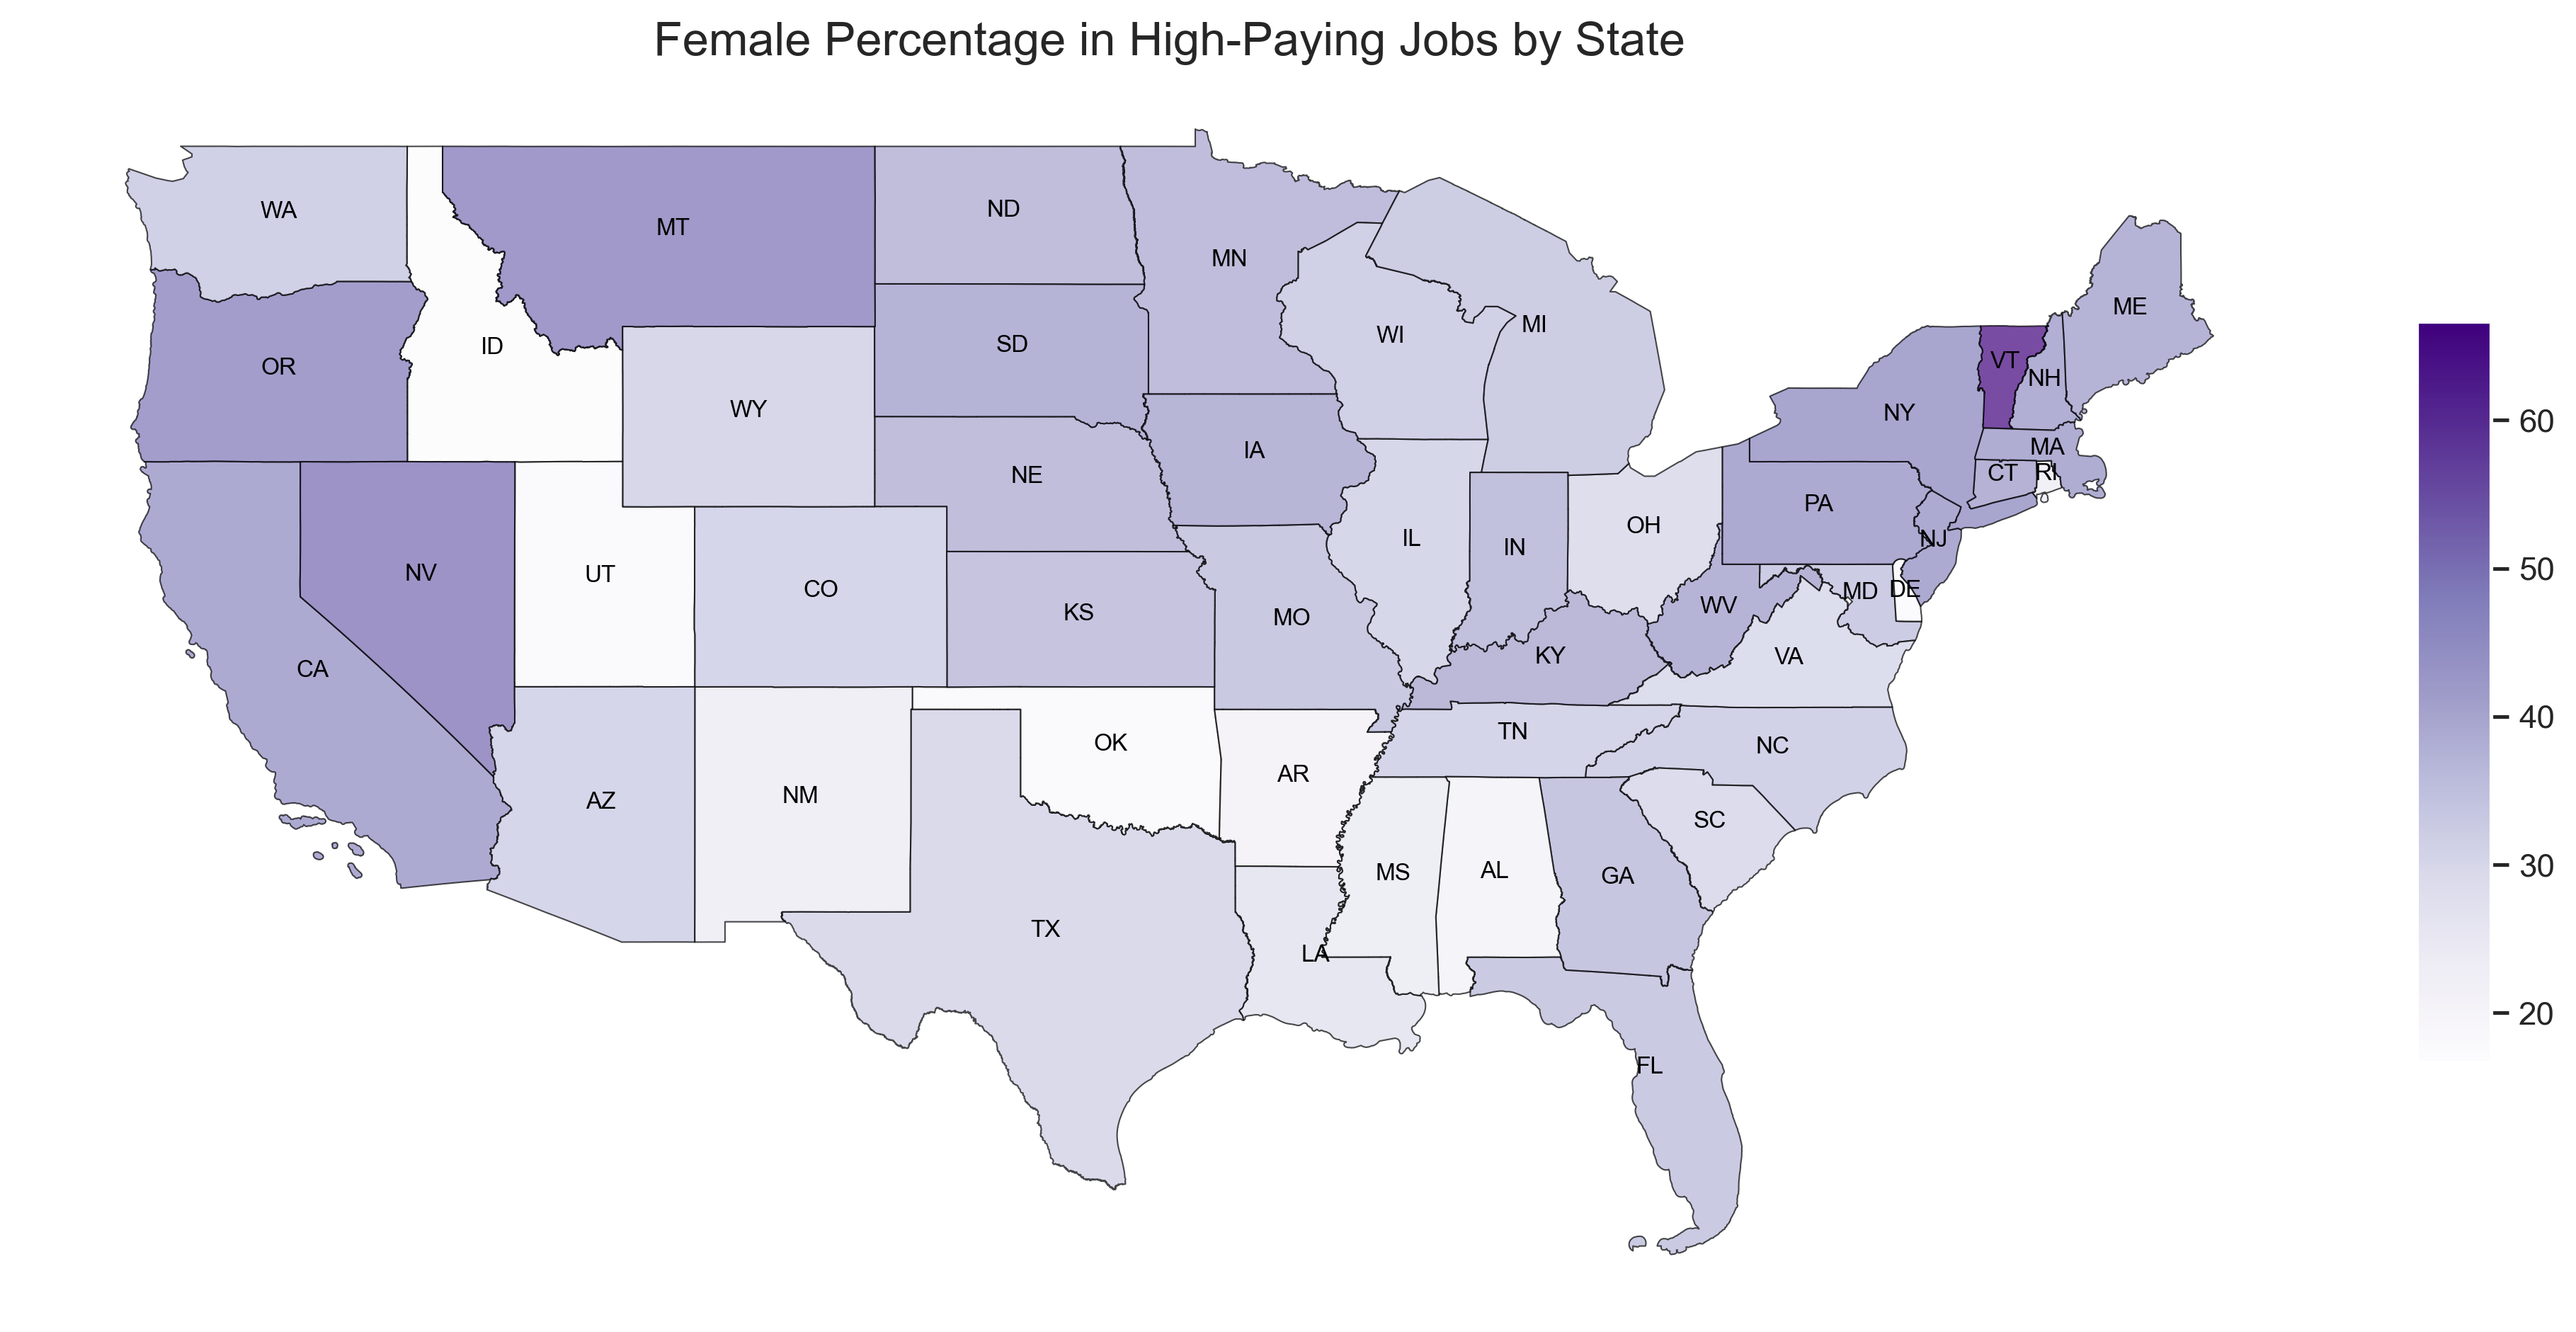

In [106]:
StatesPlot(
    df=geo_gender_df,
    column_to_plot='Female_Percentage',
    cmap='Purples',
    label_color='black',
    label_size=8,
    title='Female Percentage in High-Paying Jobs by State',  
    filename='Female_Percentage_state.png',  
    edge_color='black'
)
